In [ ]:
# shell
# python -m venv .venv       

# In cmd.exe
# .venv\Scripts\activate.bat

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
from tqdm.notebook import tqdm
from sklearn.preprocessing import MultiLabelBinarizer

import torch
import torch.nn.functional as F
from torch import nn
from torch import Tensor
from einops import rearrange, repeat
from einops.layers.torch import Rearrange

In [2]:
import umap 

f:\Documents\GitHub\MLOpsProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Explored various type of models:
- VAE: Not very effective on the categorical data, despite the sentence embedding;
- RAG: Very effective on the categorical data. We can compute the cosine similarity on each feature in the dataset.
- KNN: One hot encoding on the categorical data. Leads to very high dimensional observation.

Loading the dataset

In [3]:
# https://www.kaggle.com/datasets/infamouscoder/dataset-netflix-shows
# https://www.kaggle.com/code/samad0015/eda-on-netflix-shows
path = "netflix_encoded.csv"
df = pd.read_csv(path)
df_exposition = pd.read_csv("netflix_titles.csv")
df.shape

(8800, 2359)

### KNN

In [4]:
def scale_feature_by_factor(df, feature, factor):
    df[feature] = df[feature] * factor
    return df

def scale_cast_features(df, factor):
    # Seleziona tutte le colonne che iniziano con "cast_"
    cast_cols = [col for col in df.columns if col.startswith('cast_')]
    # Moltiplica ogni colonna per il fattore
    df[cast_cols] = df[cast_cols] * factor
    return df

def scale_director_features(df, factor):
    # Seleziona tutte le colonne che iniziano con "director_"
    director_cols = [col for col in df.columns if col.startswith('director_')]
    # Moltiplica ogni colonna per il fattore
    df[director_cols] = df[director_cols] * factor
    return df

def scale_country_features(df, factor):
    # Seleziona tutte le colonne che iniziano con "country_"
    country_cols = [col for col in df.columns if col.startswith('country_')]
    # Moltiplica ogni colonna per il fattore
    df[country_cols] = df[country_cols] * factor
    return df

def scale_listed_in_features(df, factor):
    # Seleziona tutte le colonne che iniziano con "listed_in_"
    listed_in_cols = [col for col in df.columns if col.startswith('listed_in_')]
    # Moltiplica ogni colonna per il fattore
    df[listed_in_cols] = df[listed_in_cols] * factor
    return df

df = scale_feature_by_factor(df, 'duration_final', 0.03)
df = scale_feature_by_factor(df, 'release_year', 0.001)
df = scale_feature_by_factor(df, 'rating', 2)

df = scale_cast_features(df, 1.5)
df = scale_director_features(df, 1.5)
df = scale_country_features(df, 1.5)
df = scale_listed_in_features(df, 4)

X = df.drop(columns=['show_id', 'title', 'description']).to_numpy(dtype='float32')

In [10]:
class KNN:
    def __init__(self, k=10):
        self.k = k

    def fit(self, X):
        self.X_train = X
        self.n, self.d = X.shape

    def predict(self, x):
        difference = (x - self.X_train)
        distances = np.sqrt(np.sum( difference*difference, axis=1))/self.n

        return np.argsort(distances)[1:self.k + 1]


In [11]:
knn = KNN()
knn.fit(X)

In [12]:
keys = [df.iloc[7068]["show_id"]]
df_exposition[df_exposition["show_id"].isin(keys)][["title", "country", "release_year", "rating", "listed_in"]].head(10)

,title,country,release_year,rating,listed_in
7073,Indiana Jones and the Temple of Doom,United States,1984,PG,"Action & Adventure, Children & Family Movies, ..."


In [ ]:
df_exposition[df_exposition["show_id"].isin(keys)][["title", "country", "release_year", "rating", "listed_in"]].head(10)

In [ ]:
idx_knn = knn.predict(X[7068])
keys = df.iloc[idx_knn]["show_id"].values
keys = [str(key) for key in keys]
df_exposition[df_exposition["show_id"].isin(keys)][["title", "country", "release_year", "rating", "listed_in"]].head(10)

,title,country,release_year,rating,listed_in
177,The Guns of Navarone,"United Kingdom, United States",1961,TV-14,"Action & Adventure, Classic Movies"
601,The Karate Kid,United States,1984,PG,"Action & Adventure, Children & Family Movies, ..."
819,The Outlaw Josey Wales,United States,1976,PG,"Action & Adventure, Classic Movies"
6448,Charlotte's Web,United States,1973,G,"Children & Family Movies, Classic Movies"
6496,Cleopatra Jones,United States,1973,PG,"Action & Adventure, Classic Movies"
7071,Indiana Jones and the Last Crusade,United States,1989,PG-13,"Action & Adventure, Children & Family Movies, ..."
7072,Indiana Jones and the Raiders of the Lost Ark,United States,1981,PG,"Action & Adventure, Children & Family Movies, ..."
7330,Logan's Run,United States,1976,PG,"Action & Adventure, Classic Movies, Cult Movies"
7564,National Treasure,United States,2004,PG,"Action & Adventure, Children & Family Movies"
7755,Popeye,United States,1980,PG,"Action & Adventure, Children & Family Movies, ..."


### RAG style

Model

In [7]:
from sentence_transformers import SentenceTransformer
import os
import json

In [20]:
df_clean = df_clean_backup.copy()

In [8]:
model = SentenceTransformer('all-MiniLM-L6-v2')
d_emb = model.encode('text').shape

country

In [ ]:
class MLOVIE:
    def __init__(self,  model, k = 5):
        self.model = model
        self.k = k
        self.folder = "data/"

        self.col_names = None
        self.n, self.d = None, None
        self.embeddings = {}
        self.numeric = {}
        self.w = {}
        self.type = {}
        
        self.file_names = ['embeddings.npz', 'numeric.npz', 'w.npz', 'type.npz']


    def fit(self, df, selected, w = None):
        self.n, self.d = df.shape
        w = np.ones(self.n)/self.n if w is None else w/np.sum(w)
        self.col_names = selected

        for column, w in tqdm(zip(selected, w), total=len(selected)):
            if pd.api.types.is_numeric_dtype(df[column]):
                self.numeric[column]    = df[column].to_numpy()
                self.type[column] = 'numeric'
            else:
                self.embeddings[column] = self.model.encode(df[column], normalize_embeddings=True)
                self.type[column] = 'str'

            self.w[column] = w


    def predict(self, x):
        """"x should be a dictionary"""
        scores = np.zeros((self.n, self.d))

        for i, name in enumerate(self.col_names):
            if self.type[name] == 'str':
                z = self.model.encode(x[name])
                scores[:, i] = (self.CosineSimilarity(z, self.embeddings[name]))*self.w[name]
            else:
                scores[:, i] = self.NumericScore(self.numeric[name], x[name])*self.w[name]
        
        scores = np.sum(scores, axis=1)
        idx = np.argsort(-scores)
        return idx, scores   # change with scores[idx]
    

    def save(self):
        assert self.col_names is not None, "model not fitted yet"
        print("Saving into:", os.getcwd())
        
        arg = [self.embeddings, self.numeric, self.w, self.type]
        
        for name, file in zip(self.file_names, arg):
            print(self.folder + name)
            np.savez_compressed(self.folder + name, **file)
        
        with open(self.folder + "db_info.json", "w") as file:
            json.dump([self.col_names, [self.n, self.d]], file)


    def load(self):
        arg = []
        
        for name in self.file_names:
            try:
                with np.load(self.folder + name, allow_pickle=True) as npz_file:
                    arg.append({key: npz_file[key] for key in npz_file.files})
            except Exception as e:
                raise IOError(f"Error loading {self.folder + name}: {str(e)}")

        self.embeddings, self.numeric, self.w, self.type = arg

        with open(self.folder + "db_info.json", "r") as file:
            info = json.load(file)
            self.col_names, (self.n, self.d) = info


    def NumericScore(self, x, X):
        dif = x - X
        return 1 / (np.sqrt(dif * dif) + 1)
    

    def change_w(self, w):
        for name in self.col_names:
            self.w[name] = w[name]


    def CosineSimilarity(self, z, X, sort_idx = False):
        z = np.reshape(z, (1, -1))
        norm = (np.linalg.norm(z) * np.linalg.norm(X, axis=1, keepdims=True))
        cosine_similarity = ((X @ z.T) / norm).squeeze()

        return cosine_similarity

In [10]:
selected =   ['title', 'director', 'cast', 'country', 'release_year',  'listed_in']
w = np.array([ 0.5,     0.1,          1,      1,         0.5,             2])

#selected =          ['title', 'release_year']
#w        = np.array([ 2,     0.5 ]) 

In [11]:
mlovie = MLOVIE(model)
#mlovie.fit(df_clean, selected, w)

In [500]:
mlovie.save()

Saving into: c:\Users\david\Documents\GitHub\MLOpsProject\ml
embeddings.npz
numeric.npz
w.npz
type.npz


In [12]:
mlovie.load()

In [13]:
selected2 =   ['title', 'director', 'cast', 'country', 'release_year',  'listed_in']
w2 = np.array([ 2,       0.3,        0.5,    0.1,       0.5,             4])
w2 = w2/w2.sum()

w_dict = {}
for name, w in zip(selected2, w2):
    w_dict[name] = w

mlovie.change_w(w_dict)
mlovie.w

{'title': np.float64(0.27027027027027023),
 'director': np.float64(0.040540540540540536),
 'cast': np.float64(0.06756756756756756),
 'country': np.float64(0.013513513513513514),
 'release_year': np.float64(0.06756756756756756),
 'listed_in': np.float64(0.5405405405405405)}

In [574]:
df_clean.iloc[7068]

index                                                        7073
show_id                                                     s7074
type                                                        Movie
title                        Indiana Jones and the Temple of Doom
director                                         Steven Spielberg
cast            Harrison Ford, Kate Capshaw, Amrish Puri, Rosh...
country                                             United States
release_year                                                 1984
rating                                                         PG
duration                                                  119 min
listed_in       Action & Adventure, Children & Family Movies, ...
description     Indiana Jones, his young sidekick and a spoile...
Name: 7068, dtype: object

In [14]:
idx, score = mlovie.predict(df_clean.iloc[7068])

In [15]:
df_clean.iloc[idx[1:11]]

,index,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description
7067,7072,s7073,Movie,Indiana Jones and the Raiders of the Lost Ark,Steven Spielberg,"Harrison Ford, Karen Allen, Paul Freeman, Rona...",United States,1981,PG,116 min,"Action & Adventure, Children & Family Movies, ...",When Indiana Jones is hired by the government ...
7066,7071,s7072,Movie,Indiana Jones and the Last Crusade,Steven Spielberg,"Harrison Ford, Sean Connery, Denholm Elliott, ...",United States,1989,PG-13,127 min,"Action & Adventure, Children & Family Movies, ...","Accompanied by his father, Indiana Jones sets ..."
7065,7070,s7071,Movie,Indiana Jones and the Kingdom of the Crystal S...,Steven Spielberg,"Harrison Ford, Cate Blanchett, Karen Allen, Ra...",United States,2008,PG-13,123 min,"Action & Adventure, Children & Family Movies, ...",Indiana Jones is drawn into a Russian plot to ...
601,601,s602,Movie,The Karate Kid,John G. Avildsen,"Ralph Macchio, Pat Morita, Elisabeth Shue, Mar...",United States,1984,PG,127 min,"Action & Adventure, Children & Family Movies, ...",When a bullied teen befriends an unassuming ma...
4319,4319,s4320,Movie,Mowgli: Legend of the Jungle,Andy Serkis,"Christian Bale, Cate Blanchett, Benedict Cumbe...","United Kingdom, United States",2018,PG-13,105 min,"Action & Adventure, Children & Family Movies, ...",An orphaned boy raised by animals in the jungl...
155,155,s156,Movie,Labyrinth,Jim Henson,"David Bowie, Jennifer Connelly, Frank Oz, Kevi...","United Kingdom, United States",1986,PG,101 min,"Action & Adventure, Children & Family Movies, ...","In Jim Henson's fantasy, teen Sarah embarks on..."
602,602,s603,Movie,The Karate Kid Part II,John G. Avildsen,"Ralph Macchio, Pat Morita, Nobu McCarthy, Taml...",United States,1986,PG,113 min,"Action & Adventure, Children & Family Movies, ...","Daniel and his martial-arts mentor, Mr. Miyagi..."
7557,7564,s7565,Movie,National Treasure,Jon Turteltaub,"Nicolas Cage, Diane Kruger, Justin Bartha, Sea...",United States,2004,PG,131 min,"Action & Adventure, Children & Family Movies",Modern treasure hunters search for a chest of ...
7285,7290,s7291,Movie,LEGO Ninjago: Masters of Spinjitzu: Day of the...,Unknown,Unknown,"Denmark, China",2016,TV-Y7-FV,44 min,"Action & Adventure, Children & Family Movies",Cole finds himself trapped in Yang's temple af...
810,810,s811,Movie,Streets of Fire,Walter Hill,"Michael Paré, Diane Lane, Rick Moranis, Amy Ma...",United States,1984,PG,94 min,"Action & Adventure, Classic Movies, Cult Movies",Tough ex-soldier Tom Cody springs into action ...


<br>
<br>
<br>
<br>

### Test on sentence_transformers

In [535]:
df_clean['listed_in']

0                                           Documentaries
1         International TV Shows, TV Dramas, TV Mysteries
2       Crime TV Shows, International TV Shows, TV Act...
3                                  Docuseries, Reality TV
4       International TV Shows, Romantic TV Shows, TV ...
                              ...                        
8802                       Cult Movies, Dramas, Thrillers
8803               Kids' TV, Korean TV Shows, TV Comedies
8804                              Comedies, Horror Movies
8805                   Children & Family Movies, Comedies
8806       Dramas, International Movies, Music & Musicals
Name: listed_in, Length: 8800, dtype: object

In [21]:
encoded_listed = model.encode(df_clean['listed_in'], normalize_embeddings=True)

In [17]:
UMAP = umap.UMAP()

In [18]:
reduction = UMAP.fit_transform(encoded_listed)

c:\Users\david\Documents\GitHub\MLOpsProject\.venv\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
c:\Users\david\Documents\GitHub\MLOpsProject\.venv\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


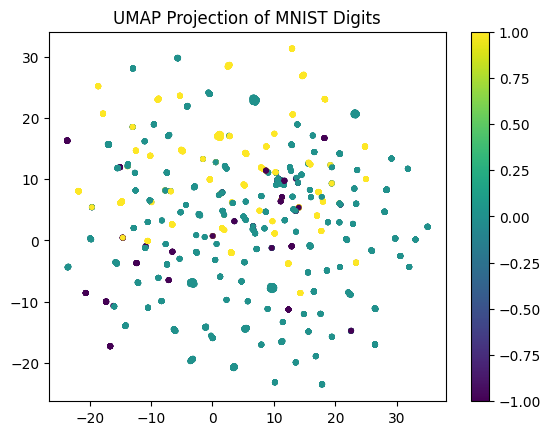

In [31]:
labels = np.zeros(df_clean.shape[0])
for i, line in enumerate(df_clean['listed_in']):
    if 'Comedies' in line:
        labels[i] = 1
    if 'Horror' in line:
        labels[i] = -1


# Plot the result
plt.scatter(reduction[:, 0], reduction[:, 1], c=labels, s=10)
plt.colorbar()
#plt.colorbar(boundaries=np.arange(11)-0.5).set_ticks(np.arange(10))
plt.title('UMAP Projection of MNIST Digits')
plt.show()

In [81]:
def CosineSimilarity(z, X, sort_idx = False):
    norm = (np.linalg.norm(z) * np.linalg.norm(X, axis=1, keepdims=True))
    cosine_similarity = ((X @ z.T) / norm).squeeze()
    
    idx = np.argsort(-cosine_similarity.squeeze()) if sort_idx else None

    return cosine_similarity, idx

<br>